<a href="https://colab.research.google.com/github/gfarhani/Quantum_Computing/blob/main/Chapter_2/QM_DJ_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.8 MB/s eta 0:00:00


In [ ]:
pip install qiskit_aer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 26.9 MB/s eta 0:00:00


In [ ]:
!pip -q install matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# Explanation of the libraries:
    
    1) QuantumCircuit is the main object you use to build a quantum circuit. So, think of it like a “canvas” where you place gates (H, X, CNOT, measure, …).

    2) Aer gives you simulators (so you can run the circuit on your computer). Example simulator: aer_simulator (pretends to be a quantum computer).

    3) transpile means: “rewrite my circuit into a form the backend understands best.” Different backends (simulators or real devices) have different allowed gate sets and connectivity.
    So, Transpiling makes it runnable and often more efficient.

# Explanation of the Oracle for a constant fucntion:

    Constant oracle: f(x) = output_bit for all x.
    Okay remember we know that if f(x) is a constant function it means that what ever the x is f(x) is always either 0 or 1.
    So, also we know that for a constant function the Oracle ALWAYS outputs 0. In this case if the output of the fucntion (f(x)) is 0,
    The Oracle does not do any thing but if the output of (f(x)) is 1, it flips it to 0 which means it uses CNOT
    U_f |x>|y> = |x>|y XOR f(x)>
    If output_bit=1, we just flip the output qubit.

# On the Circuit builup:
   
   We have n input bits, so the size of Quantum Circuit is n+1, because we need one extra bit for the output (y).
  Qiskit numbers them: input: 0, 1, ..., n-1 & output: n (the last one)

# Explanation of the Oracle for a balanced function:

### Why the “mask” oracle is balanced (intuition)

In Deutsch–Jozsa, a Boolean function \(f:\{0,1\}^n \to \{0,1\}\) is **balanced** if it outputs 0 on exactly half of the \(2^n\) inputs and 1 on the other half.

A common balanced family is
\[
f(x) = (m \cdot x)\bmod 2,
\]
where \(m \in \{0,1\}^n\) is a **nonzero mask** and the dot product is taken **mod 2** (so it is the XOR of the selected input bits).

The Deutsch–Jozsa oracle is defined by
\[
U_f\,|x\rangle|y\rangle = |x\rangle\,|y \oplus f(x)\rangle,
\]
i.e., it flips the output qubit \(y\) if (and only if) \(f(x)=1\).

**Why this is balanced when \(m \neq 0\):**  
If the mask is nonzero, there exists at least one index \(k\) with \(m_k = 1\).  
Now pair every input \(x\) with \(x' = x \oplus e_k\) (same bits as \(x\), except the \(k\)-th bit is flipped). Because \(x_k\) appears in the XOR defining \(f(x)\), flipping \(x_k\) flips the value of \(f\):
\[
f(x') = f(x)\oplus 1.
\]
So in each pair, one input gives \(f=0\) and the other gives \(f=1\). Therefore, across all inputs, \(f(x)\) is 0 for half and 1 for half — i.e., \(f\) is **balanced**.

**Example:** \(n = 3\) and `mask = [1, 0, 1]`

This defines the Boolean function
\[
f(x_0, x_1, x_2) = x_0 \oplus x_2
\]
(i.e., XOR of the selected bits)

Now list all inputs and compute \(f\):

| \(x_0x_1x_2\) | \(x_0\) | \(x_2\) | \(x_0 \oplus x_2\) |
|---|---:|---:|---:|
| 000 | 0 | 0 | 0 |
| 001 | 0 | 1 | 1 |
| 010 | 0 | 0 | 0 |
| 011 | 0 | 1 | 1 |
| 100 | 1 | 0 | 1 |
| 101 | 1 | 1 | 0 |
| 110 | 1 | 0 | 1 |
| 111 | 1 | 1 | 0 |

Count the outputs:

- Zeros: 000, 010, 101, 111 → **4**
- Ones: 001, 011, 100, 110 → **4**

✅ Exactly half-half → **balanced**.

In [ ]:
# Deutsch–Jozsa in Qiskit (Qiskit 1.x style)
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit import transpile

""" Explanation of the libraries:

    1) QuantumCircuit is the main object you use to build a quantum circuit. So, think of it like a “canvas” where you place gates (H, X, CNOT, measure, …).

    2) Aer gives you simulators (so you can run the circuit on your computer). Example simulator: aer_simulator (pretends to be a quantum computer).

    3) transpile means: “rewrite my circuit into a form the backend understands best.” Different backends (simulators or real devices) have different allowed gate sets and connectivity.
    So, Transpiling makes it runnable and often more efficient.
"""


def dj_oracle_constant(n, output_bit=0):
    """
    Constant oracle: f(x) = output_bit for all x.
    Okay remember we know that if f(x) is a constant function it means that what ever the x is f(x) is always either 0 or 1.
    So, also we know that for a constant function the Oracle ALWAYS outputs 0. In this case if the output of the fucntion (f(x)) is 0,
    The Oracle does not do any thing but if the output of (f(x)) is 1, it flips it to 0 which means it uses CNOT
    U_f |x>|y> = |x>|y XOR f(x)>
    If output_bit=1, we just flip the output qubit.
    """

    """
    We have n input bits, so the size of Quantum Circuit is n+1, because we need one extra bit for the output (y).
    Qiskit numbers them: input: 0, 1, ..., n-1 & output: n (the last one)
    """
    #build the Quantum Circuit
    qc = QuantumCircuit(n + 1)
    if output_bit == 1:
        qc.x(n)  # output qubit is the last one, applies an X gate (NOT gate) on qubit n
    return qc

def dj_oracle_balanced(n, mask=None):
    """
    Balanced oracle example: f(x) = (mask · x) mod 2 with mask != 0.
    This is balanced for any nonzero mask.
    Oracle implemented by CNOTs from selected input qubits to output qubit.
    """
    if mask is None:
        mask = [1] + [0]*(n-1)  # simplest nonzero mask
    if all(b == 0 for b in mask):
        raise ValueError("Mask must be nonzero for a balanced oracle.")

    qc = QuantumCircuit(n + 1)
    for i, bit in enumerate(mask):
        if bit == 1:
            qc.cx(i, n)  # control from input i to output qubit
    return qc

In [ ]:
""" To understand this bit you need to look at the lecture notes! """

def deutsch_jozsa_circuit(n, oracle: QuantumCircuit):
    """
    Builds the full DJ circuit on n input qubits + 1 output qubit.
    Measures only the input register.
    """
    qc = QuantumCircuit(n + 1, n)

    # 1) Prepare |0...0>|1>
    qc.x(n)

    # 2) Apply H to all qubits
    qc.h(range(n + 1))

    # 3) Apply oracle
    qc.compose(oracle, inplace=True)

    # 4) Apply H to input register only
    qc.h(range(n))

    # 5) Measure input qubits
    qc.measure(range(n), range(n))

    return qc

In [ ]:
"""
def run_and_classify(qc, shorts = 1024):
Defines a function that:

1) takes a quantum circuit qc

2) runs it shots times (default 1024)

3) returns the measurement counts + a label (“CONSTANT” or “BALANCED”)"""

def run_and_classify(qc, shots=1024):
    # Chooses the Aer simulator backend (a fake quantum computer running on your laptop).
    backend = Aer.get_backend("aer_simulator")
    # “Compiles” your circuit for that simulator backend
    tqc = transpile(qc, backend)
    # Runs the transpiled circuit shots times and grabs the result object.
    result = backend.run(tqc, shots=shots).result()
    counts = result.get_counts()
    # get a dictinary like: {'0000': 1024} or {'1011': 520, '0101': 504}

    # In ideal DJ: constant -> always all-zeros outcome on input
    # balanced -> never all-zeros outcome on input (in the noiseless case)
    n = qc.num_clbits
    zeros = "0"*n
    if counts.get(zeros, 0) == shots:
        verdict = "CONSTANT"
    elif counts.get(zeros, 0) == 0:
        verdict = "BALANCED"
    else:
        verdict = "INCONCLUSIVE (noise / non-ideal oracle / finite shots)"

    return counts, verdict


In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

def show_circuit_mpl(qc, title=None, fold=30):
    fig = qc.draw(output="mpl", fold=fold)  # returns a matplotlib Figure
    if title:
        fig.suptitle(title)
    display(fig)
    plt.close(fig)  # avoids duplicate/blank figures sometimes



In [ ]:
# --- Demo ---
n = 4

oracle_const0 = dj_oracle_constant(n, output_bit=0)
qc_const0 = deutsch_jozsa_circuit(n, oracle_const0)

oracle_const1 = dj_oracle_constant(n, output_bit=1)
qc_const1 = deutsch_jozsa_circuit(n, oracle_const1)

oracle_bal = dj_oracle_balanced(n, mask=[1,0,1,1])  # any nonzero mask
qc_bal = deutsch_jozsa_circuit(n, oracle_bal)

for name, qc in [("constant f=0", qc_const0),
                 ("constant f=1", qc_const1),
                 ("balanced", qc_bal)]:
    counts, verdict = run_and_classify(qc, shots=1024)
    print(name, "->", verdict, counts)




constant f=0 -> CONSTANT {'0000': 1024}
constant f=1 -> CONSTANT {'0000': 1024}
balanced -> BALANCED {'1101': 1024}


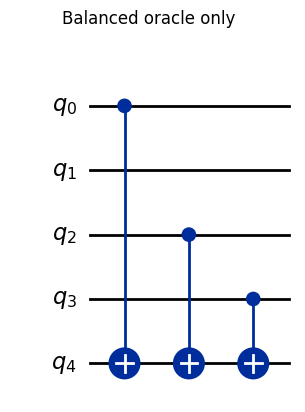

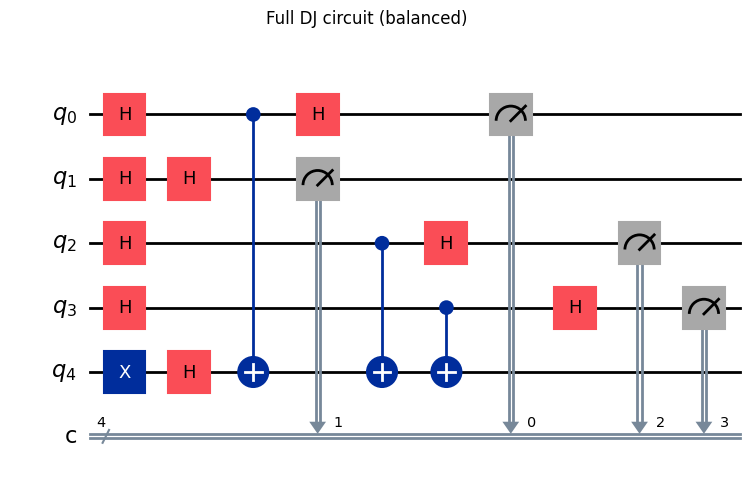

In [ ]:
show_circuit_mpl(oracle_bal, title="Balanced oracle only")
show_circuit_mpl(qc_bal, title="Full DJ circuit (balanced)")